**1. Importation des bibliothèques et des données**

In [25]:
# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_diabetes

# Séparation et validation
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold,
    GridSearchCV,
    RandomizedSearchCV
)

# Prétraitement
from sklearn.preprocessing import StandardScaler

# Pipeline
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Évaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Interprétation
from sklearn.inspection import permutation_importance

In [26]:
# Importation du dataset Diabetes
from sklearn import datasets

# Données utilisées pour la modélisation
X, y = datasets.load_diabetes(return_X_y=True)

# Informations descriptives du dataset
diabetes = datasets.load_diabetes()

**2. Compréhension et description du dataset**

In [27]:
# Compréhension et description du dataset

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

print("\nVariables explicatives :")
print(diabetes.feature_names)

Dimensions de X : (442, 10)
Dimensions de y : (442,)

Variables explicatives :
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [28]:
# Afficher la description du dataset
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [29]:
# Examiner les premières observations
print("Premières observations de X :")
print(X[:5])

print("Premières observations de y :")
print(y[:5])

Premières observations de X :
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
Premières observations de y :
[151.  75. 141. 206. 135.]


In [30]:
# Afficher les informations sur les DataFrames

# Créer un DataFrame pour les variables explicatives
X = pd.DataFrame(
    X,
    columns=diabetes.feature_names
)

# Afficher les informations sur le DataFrame
print(X.info())

# Afficher les informations sur la série cible
y = pd.Series(y, name="target")

print(y.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB
None
<class 'pandas.core.series.Series'>
RangeIndex: 442 entries, 0 to 441
Series name: target
Non-Null Count  Dtype  
--------------  -----  
442 non-null    float64
dtypes: float64(1)
memory usage: 3.6 KB
None


**3. Exploration des données (EDA)**

In [31]:
# Vérification des types et de la structure
print("Type de X :", type(X))
print("Type de y :", type(y))

Type de X : <class 'pandas.core.frame.DataFrame'>
Type de y : <class 'pandas.core.series.Series'>


In [32]:
# Vérifier les valeurs manquantes
print("Valeurs manquantes dans X :", np.isnan(X).sum())
print("Valeurs manquantes dans y :", np.isnan(y).sum())

Valeurs manquantes dans X : age    0
sex    0
bmi    0
bp     0
s1     0
s2     0
s3     0
s4     0
s5     0
s6     0
dtype: int64
Valeurs manquantes dans y : 0


In [33]:
# Vérifier les statistiques descriptives de X
print("Statistiques descriptives de X :")
print(pd.DataFrame(X, columns=diabetes.feature_names).describe())

Statistiques descriptives de X :
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.268604e-17  1.130318e-17  
std    4.761905e-02  

In [34]:
# Vérifier les statistiques descriptives de Y (la variable cible)
print("\nStatistiques descriptives de y :")
print(pd.Series(y).describe())


Statistiques descriptives de y :
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64


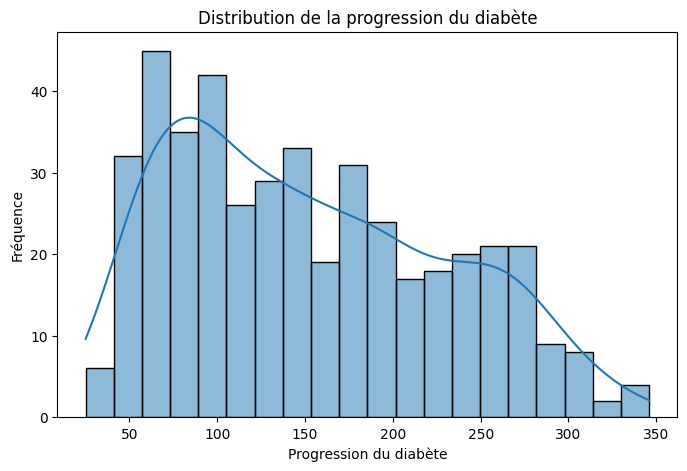

In [35]:
# Visualisation de la distribution de la variable cible (progression du diabète)
plt.figure(figsize=(8, 5))

sns.histplot(y, bins=20, kde=True)

plt.title("Distribution de la progression du diabète")
plt.xlabel("Progression du diabète")
plt.ylabel("Fréquence")

plt.show()

In [36]:
# Calcul de l'asymétrie :

print("Skewness :", pd.Series(y).skew())

Skewness : 0.44056293407014124


In [37]:
# Calcul de la Kurtosis de la variable cible
kurtosis_y = pd.Series(y).kurtosis()
print("Kurtosis de y :", kurtosis_y)

Kurtosis de y : -0.8830573344098585


In [38]:
# Affichage des valeurs uniques et de leur fréquence
print(pd.Series(y).value_counts().sort_index())

target
25.0     1
31.0     1
37.0     1
39.0     2
40.0     1
        ..
321.0    1
332.0    1
336.0    1
341.0    1
346.0    1
Name: count, Length: 214, dtype: int64


Quelles variables semblent avoir une relation avec la progression du diabète (target) ?

In [39]:
# Création du DataFrame
df = pd.DataFrame(
    X,
    columns=diabetes.feature_names
)

# Ajout de la variable cible
df["target"] = y


# Corrélations de Pearson
# Est-ce que deux variables évoluent ensemble de manière approximativement linéaire ?
corr_pearson = df.corr(method="pearson")

print("Corrélations de Pearson avec target :")
print(corr_pearson["target"].sort_values(ascending=False))


# Corrélations de Spearman
# Quand X augmente, Y a-t-elle globalement tendance à augmenter ou diminuer ?
corr_spearman = df.corr(method="spearman")

print("\nCorrélations de Spearman avec target :")
print(corr_spearman["target"].sort_values(ascending=False))

Corrélations de Pearson avec target :
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

Corrélations de Spearman avec target :
target    1.000000
s5        0.589416
bmi       0.561382
s4        0.448931
bp        0.416241
s6        0.350792
s1        0.232429
age       0.197822
s2        0.195834
sex       0.037401
s3       -0.410022
Name: target, dtype: float64


L'analyse des corrélations de Pearson montre que bmi (r = 0,586) et s5 (r = 0,566) présentent les associations positives les plus fortes avec la progression du diabète. bp, s4 et s6 présentent également des associations positives modérées. À l'inverse, s3 présente une association négative modérée avec la cible (r = -0,395). Les corrélations de Spearman conduisent à des résultats globalement similaires, ce qui confirme la cohérence des principales associations observées.

Quelles variables explicatives sont fortement corrélées entre elles ?

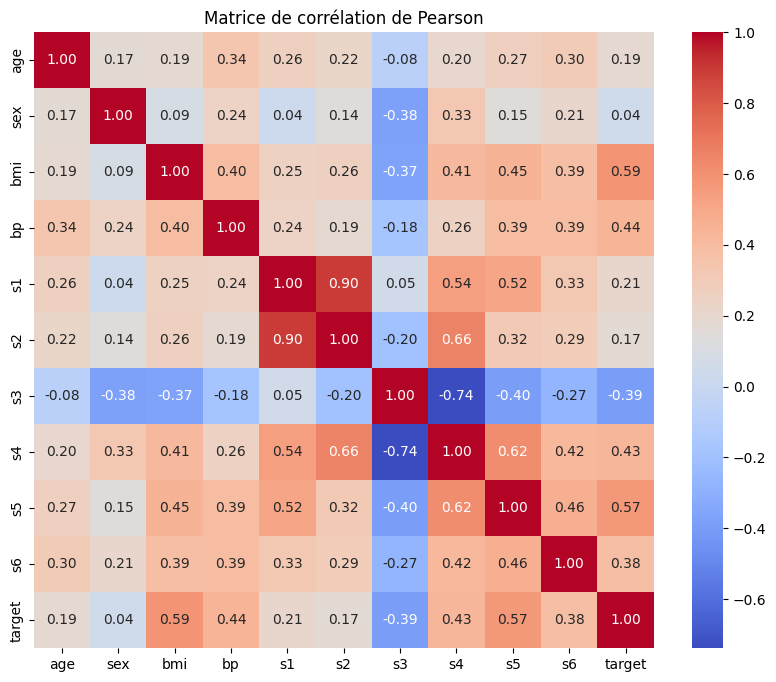

In [40]:
# Calcul et visualisation de la matrice de corrélation de Pearson

corr_pearson = df.corr(method="pearson")

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_pearson,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation de Pearson")
plt.show()

La matrice de corrélation de Pearson confirme que bmi et s5 présentent les associations positives les plus fortes avec la progression du diabète. Elle met également en évidence plusieurs corrélations importantes entre variables explicatives, notamment entre s1 et s2 (r = 0,90), entre s3 et s4 (r = -0,74), entre s2 et s4 (r = 0,66) et entre s4 et s5 (r = 0,62). Ces résultats suggèrent une possible multicolinéarité qui devra être vérifiée avant la modélisation.

**Vérification de la multicolinéarité avec le VIF**

Il mesure dans quelle mesure la variance estimée du coefficient d'une variable explicative est augmentée à cause de sa relation avec les autres variables explicatives.

Autrement dit, le VIF répond à la question :

*Est-ce que cette variable apporte une information suffisamment indépendante des autres variables explicatives ?*

In [41]:
# Vérification de la multicolinéarité avec le VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calcul des VIF pour les variables explicatives
vif = pd.DataFrame()

vif["Variable"] = diabetes.feature_names

vif["VIF"] = [
    variance_inflation_factor(X, i)
    for i in range(X.shape[1])
]

print(vif.sort_values("VIF", ascending=False))

  Variable        VIF
4       s1  59.202510
5       s2  39.193370
6       s3  15.402156
8       s5  10.075967
7       s4   8.890986
2      bmi   1.509437
9       s6   1.484623
3       bp   1.459428
1      sex   1.278071
0      age   1.217307


L'analyse du VIF met en évidence une multicolinéarité importante entre plusieurs variables explicatives. Les VIF les plus élevés concernent s1 (59,20), s2 (39,19), s3 (15,40) et s5 (10,08), tandis que s4 présente également un niveau élevé (8,89). À l'inverse, age, sex, bp, bmi et s6 présentent des VIF faibles, compris entre 1,22 et 1,51. Ces résultats confirment les corrélations observées précédemment dans la heatmap et indiquent une forte redondance entre certaines variables biologiques.

Quelles variables présentent des observations statistiquement éloignées du reste des données ?

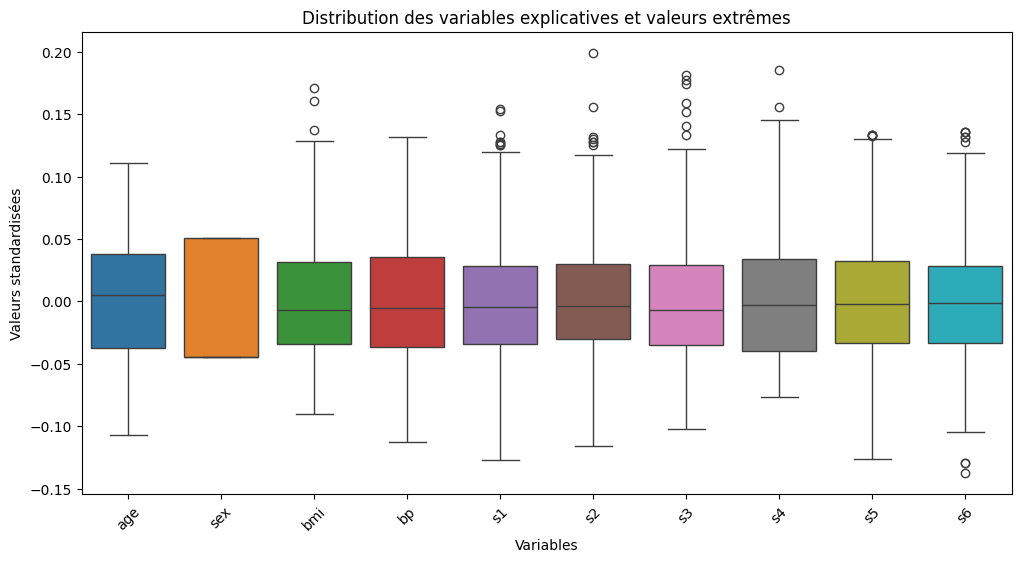

In [42]:
# Analyse des valeurs extrêmes avec les boxplots

plt.figure(figsize=(12, 6))

sns.boxplot(data=df[diabetes.feature_names])

plt.title("Distribution des variables explicatives et valeurs extrêmes")
plt.xlabel("Variables")
plt.ylabel("Valeurs standardisées")

plt.xticks(rotation=45)

plt.show()

L'analyse des boxplots met en évidence quelques observations statistiquement atypiques, principalement pour le bmi et plusieurs mesures biologiques (s1 à s6). Cependant, ces observations ne peuvent pas être considérées comme des anomalies médicales ou des erreurs de mesure sur la seule base de leur position statistique. Les variables ayant été centrées et standardisées dans le dataset source, leurs valeurs ne correspondent pas directement à des unités cliniques interprétables.

Dans une perspective métier, ces observations doivent donc être considérées comme des profils potentiellement atypiques de patients plutôt que comme des données erronées. Leur suppression ne serait pas justifiée sans informations supplémentaires sur les mesures originales, les plages de référence cliniques ou les conditions de collecte. Elles seront par conséquent conservées pour la modélisation et leur influence sera évaluée à travers les performances des modèles.

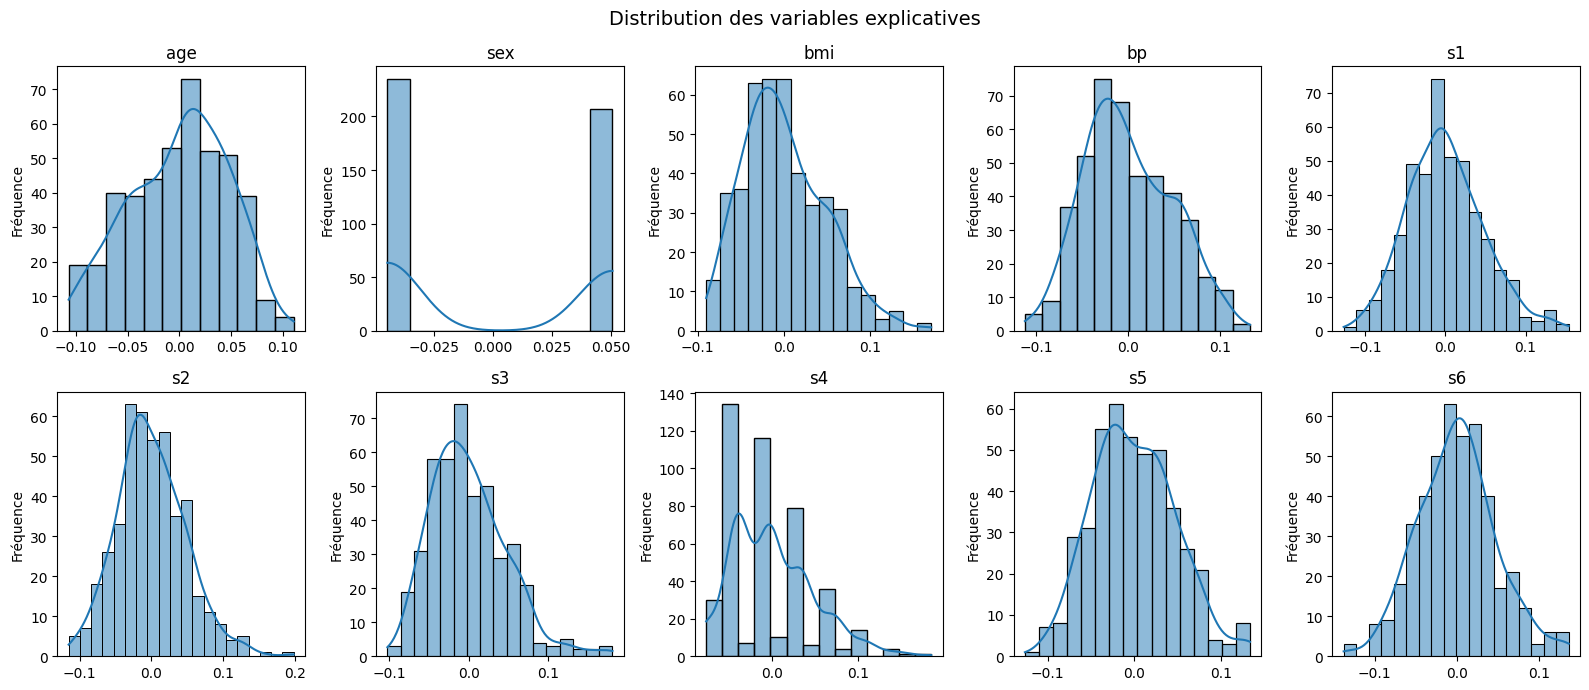

In [43]:
# Analyse des distributions des variables explicatives

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

for i, column in enumerate(diabetes.feature_names):
    sns.histplot(
        df[column],
        kde=True,
        ax=axes[i // 5, i % 5]
    )
    
    axes[i // 5, i % 5].set_title(column)
    axes[i // 5, i % 5].set_xlabel("")
    axes[i // 5, i % 5].set_ylabel("Fréquence")

plt.suptitle("Distribution des variables explicatives", fontsize=14)
plt.tight_layout()
plt.show()

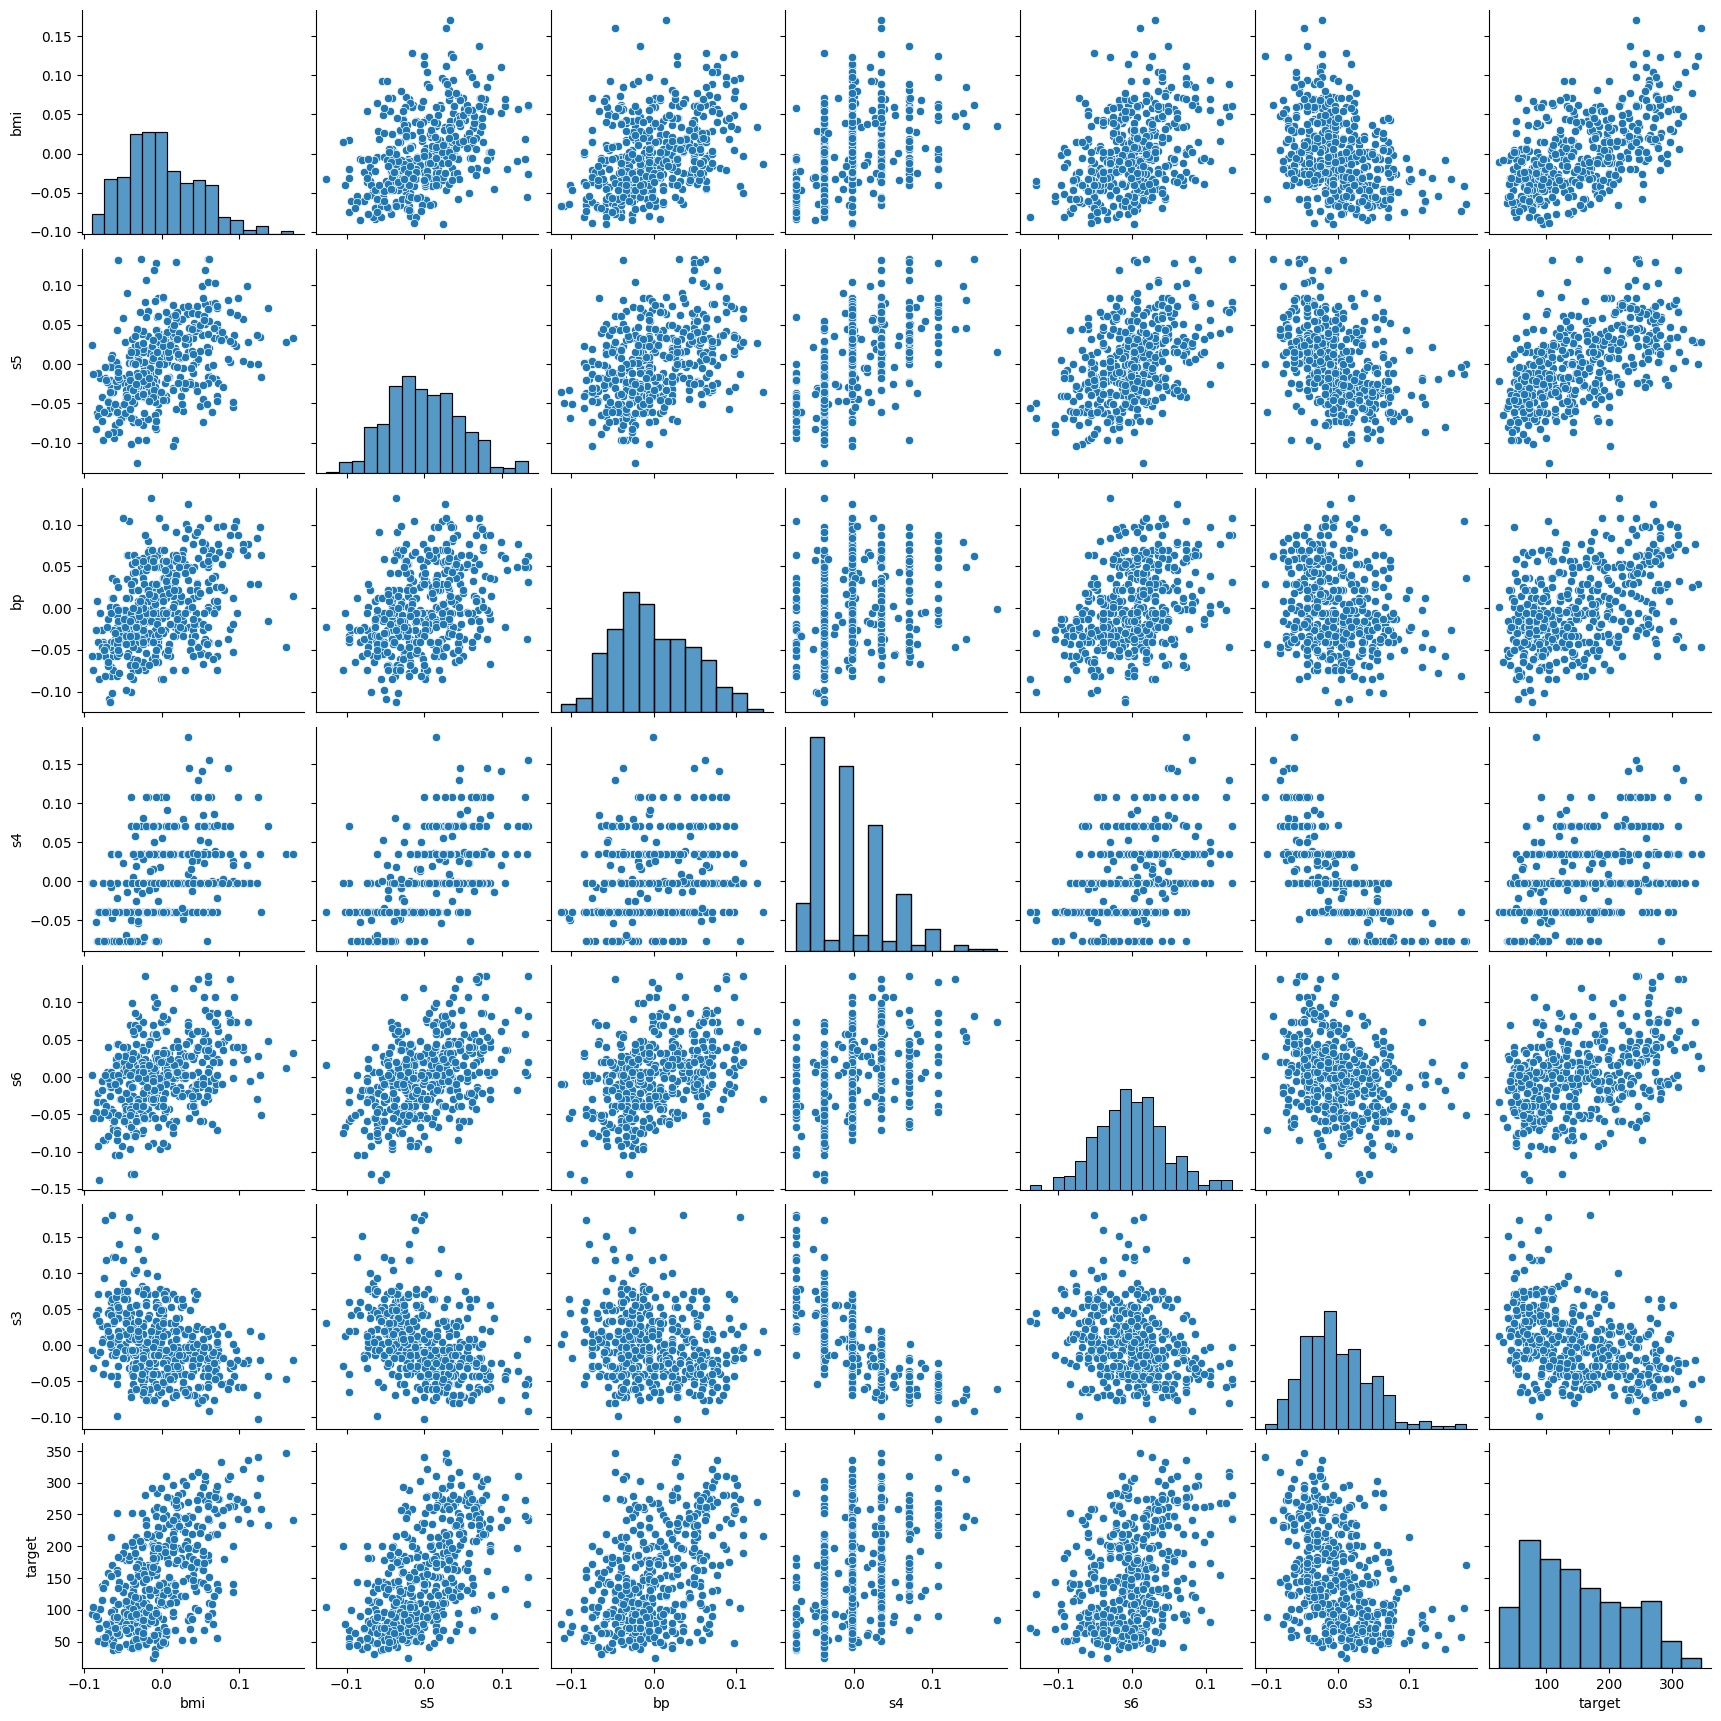

In [44]:
# Analyse des relations entre les variables les plus importantes

variables = ["bmi", "s5", "bp", "s4", "s6", "s3", "target"]

sns.pairplot(
    df[variables],
    diag_kind="hist"
)

plt.show()

L'analyse graphique confirme les principales associations identifiées par la matrice de corrélation. bmi présente la relation positive la plus marquée avec la progression du diabète, tandis que s3 présente une association négative. Les relations entre certaines variables explicatives sont également importantes, notamment entre s1 et s2, dont le nuage de points révèle une relation quasi linéaire, cohérente avec leur coefficient de corrélation de 0,90 et leurs VIF élevés. Ces observations confirment l'existence de relations importantes entre les variables et justifient une attention particulière à la multicolinéarité lors de la phase de modélisation.

**4. Préparation des données**

In [45]:
# Séparation des variables explicatives et de la cible

X = df.drop("target", axis=1)
y = df["target"]

print("Dimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Dimensions de X : (442, 10)
Dimensions de y : (442,)


In [46]:
# Séparation des données en entraînement et test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (353, 10)
X_test  : (89, 10)
y_train : (353,)
y_test  : (89,)


Les données sont correctement séparées en 353 observations pour l'entraînement et 89 observations pour le test, soit environ 80 % / 20 %. Le jeu de test sera conservé à part et servira à évaluer la capacité de généralisation des modèles.

Les variables explicatives étant déjà standardisées dans le dataset source, nous conservons leur transformation telle quelle et n'appliquons pas de deuxième standardisation pour les premiers modèles

In [47]:
# Vérification finale des données

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test  :", X_test.shape)

print("\nValeurs manquantes dans X_train :")
print(X_train.isnull().sum().sum())

print("\nValeurs manquantes dans X_test :")
print(X_test.isnull().sum().sum())

print("\nTypes des variables :")
print(X_train.dtypes)

Dimensions de X_train : (353, 10)
Dimensions de X_test  : (89, 10)

Valeurs manquantes dans X_train :
0

Valeurs manquantes dans X_test :
0

Types des variables :
age    float64
sex    float64
bmi    float64
bp     float64
s1     float64
s2     float64
s3     float64
s4     float64
s5     float64
s6     float64
dtype: object


**5. Modélisation**

**5.1. Regression Linéaire**

In [48]:
# Création du modèle
model_lr = LinearRegression()

# Entraînement
model_lr.fit(X_train, y_train)

print("Modèle entraîné avec succès.")

Modèle entraîné avec succès.


In [49]:
# Prédictions sur le jeu de test

y_pred_lr = model_lr.predict(X_test)

print(y_pred_lr[:10])

[139.5475584  179.51720835 134.03875572 291.41702925 123.78965872
  92.1723465  258.23238899 181.33732057  90.22411311 108.63375858]


In [50]:
# Comparaison entre les valeurs réelles et les prédictions

comparaison = pd.DataFrame({
    "Valeur réelle": y_test.values,
    "Prédiction": y_pred_lr
})

print(comparaison.head(10))

   Valeur réelle  Prédiction
0          219.0  139.547558
1           70.0  179.517208
2          202.0  134.038756
3          230.0  291.417029
4          111.0  123.789659
5           84.0   92.172347
6          242.0  258.232389
7          272.0  181.337321
8           94.0   90.224113
9           96.0  108.633759


In [51]:
# Évaluation quantitative du modèle

# Calcul des métriques
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("RMSE :", rmse)
print("R² :", r2)

MAE : 42.79409467959994
RMSE : 53.85344583676592
R² : 0.4526027629719197


Mon modèle se trompe en moyenne d'environ 42,8 points. Les grosses erreurs sont assez importantes puisque le RMSE monte à 53,9. Le R² de 0,453 signifie que le modèle explique 45,3 % de la variabilité de la progression du diabète. C'est donc une baseline correcte, mais il reste une marge d'amélioration.

In [52]:
# Coefficients de la régression linéaire

coefficients = pd.DataFrame({
    "Variable": X_train.columns,
    "Coefficient": model_lr.coef_
})

coefficients = coefficients.sort_values(
    "Coefficient",
    ascending=False
)

print(coefficients)

  Variable  Coefficient
8       s5   736.198859
2      bmi   542.428759
5       s2   518.062277
3       bp   347.703844
7       s4   275.317902
6       s3   163.419983
9       s6    48.670657
0      age    37.904021
1      sex  -241.964362
4       s1  -931.488846


L'analyse des coefficients montre que s5, bmi et s2 présentent les coefficients positifs les plus élevés, tandis que s1 possède un coefficient négatif important. Cependant, l'interprétation individuelle de ces coefficients doit être prudente en raison de la multicolinéarité identifiée précédemment. Les divergences observées entre certaines corrélations simples et les coefficients du modèle, notamment pour s1 et s3, illustrent l'influence des relations entre variables explicatives sur les estimations de la régression linéaire.

In [53]:
# Validation croisée avec R²

scores = cross_val_score(
    LinearRegression(),
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Scores R² :", scores)
print("R² moyen :", scores.mean())
print("Écart-type :", scores.std())

Scores R² : [0.54760189 0.36123934 0.50481226 0.61773622 0.21489265]
R² moyen : 0.4492564741221218
Écart-type : 0.144095182058588


La validation croisée à 5 folds donne un R² moyen de 0,449, proche du R² de 0,453 obtenu sur le jeu de test. Cette proximité suggère que la performance observée sur le test est globalement représentative. Cependant, l'écart-type de 0,144 et la variation des scores entre les folds, allant de 0,215 à 0,618, montrent une certaine variabilité des performances selon les sous-échantillons. La régression linéaire constitue ainsi une baseline pertinente, mais ses performances restent perfectibles et justifient la comparaison avec d'autres modèles.

In [54]:
# Calcul des résidus

residus = y_test - y_pred_lr

print(residus[:10])

287     79.452442
211   -109.517208
72      67.961244
321    -61.417029
73     -12.789659
418     -8.172347
367    -16.232389
354     90.662679
281      3.775887
148    -12.633759
Name: target, dtype: float64


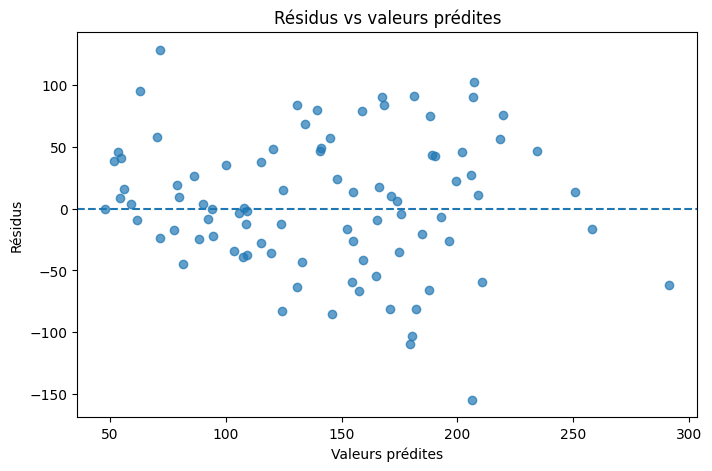

In [55]:
# Visualisation des residus

plt.figure(figsize=(8, 5))

plt.scatter(y_pred_lr, residus, alpha=0.7)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Résidus vs valeurs prédites")

plt.show()

L'analyse des résidus montre une dispersion globalement autour de zéro, sans structure courbe clairement identifiable. Cependant, la dispersion des erreurs n'est pas parfaitement homogène sur l'ensemble des valeurs prédites et certaines observations présentent des résidus importants. Ces éléments suggèrent que la régression linéaire capture une partie de la relation entre les variables explicatives et la progression du diabète, mais qu'elle ne permet pas de représenter parfaitement toutes les variations observées.

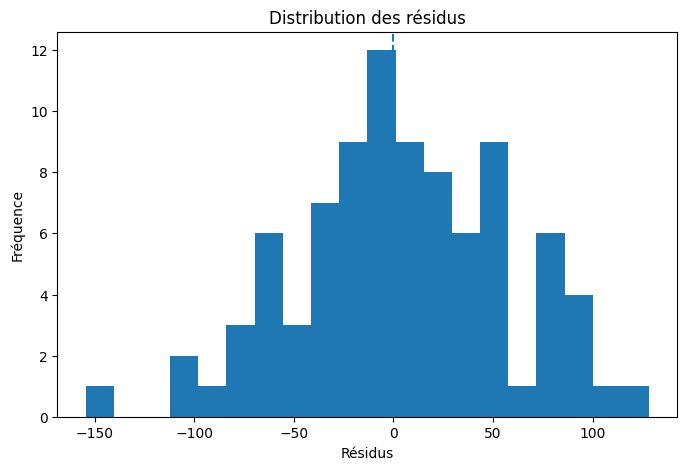

In [56]:
# Histogramme des résidus
plt.figure(figsize=(8, 5))

plt.hist(residus, bins=20)

plt.axvline(0, linestyle="--")

plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.title("Distribution des résidus")

plt.show()

L'histogramme des résidus montre une concentration des erreurs autour de zéro, avec des résidus positifs et négatifs. La majorité des erreurs se situe dans les intervalles proches de zéro, tandis que quelques observations présentent des erreurs plus importantes. Cette dispersion des erreurs est cohérente avec l'écart entre le MAE de 42,79 et le RMSE de 53,85. La distribution ne montre pas de biais directionnel évident à première vue, mais la moyenne des résidus permettra de vérifier plus précisément ce point.

In [57]:
# Vérifier le biais moyen

print("Moyenne des résidus :", residus.mean())
print("Écart-type des résidus :", residus.std())

Moyenne des résidus : 3.9128403750778027
Écart-type des résidus : 54.015424404184294


La moyenne des résidus est de 3,91, une valeur proche de zéro qui indique l'absence de biais systématique important, malgré une légère tendance à la sous-estimation. L'écart-type des résidus est de 54,02, traduisant une dispersion relativement importante des erreurs autour de leur moyenne. Ces résultats confirment que la régression linéaire produit des prédictions globalement équilibrées, mais avec une variabilité des erreurs encore importante.

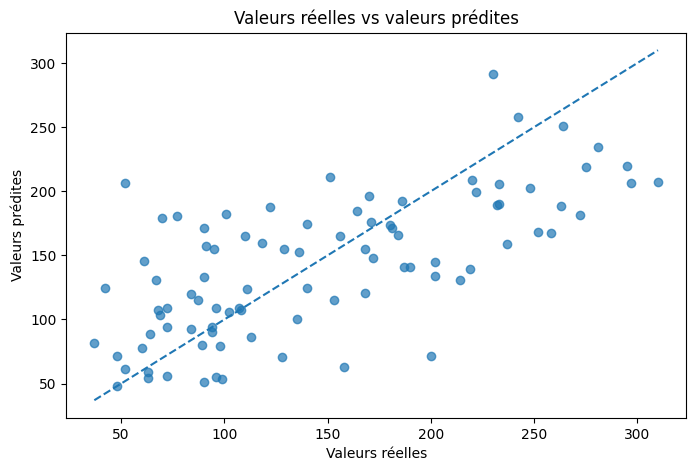

In [58]:
# Visualisation des valeurs réelles vs valeurs prédites

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# Ligne de prédiction parfaite
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Valeurs réelles vs valeurs prédites")

plt.show()

Les points suivent globalement la diagonale, donc le modèle capture la tendance générale. Cependant, ils sont assez dispersés, ce qui montre que les prédictions ne sont pas toujours proches des valeurs réelles. On observe notamment une tendance à surestimer certaines faibles valeurs et à sous-estimer certaines valeurs élevées. Cela explique en partie notre R² de 0,453 et notre RMSE de 53,85.

In [94]:
# Standardisation des variables explicatives pour mettre toutes les variables sur une échelle comparable

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**5.2. Régression Ridge**

In [95]:
# Création du modèle Ridge avec standardisation des variables explicatives

model_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

# Entraînement
model_ridge.fit(X_train, y_train)

print("Modèle Ridge entraîné avec succès.")

Modèle Ridge entraîné avec succès.


In [96]:
# Prédictions sur le jeu de test

y_pred_ridge = model_ridge.predict(X_test)

# Évaluation du Ridge simple
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("MAE :", mae_ridge)
print("RMSE :", rmse_ridge)
print("R² :", r2_ridge)

MAE : 42.81199941834888
RMSE : 53.77745406534389
R² : 0.45414652070698236


La standardisation améliore nettement les performances du Ridge. Avec alpha = 1.0, le modèle atteint un R² de 0,454, proche de la régression linéaire. L'optimisation de l'alpha permettra de vérifier si la régularisation peut encore améliorer ces performances.

**Optimisation des hyperparamètres du Ridge**

**Ridge optimisé**

Meilleur alpha : 10
Meilleur R² CV : 0.453937415795935
MAE : 42.85682524780061
RMSE : 53.626287568895194
R² : 0.45721095677808476
Moyenne des résidus : 3.8969692063645383
Écart-type des résidus : 53.484505694887844


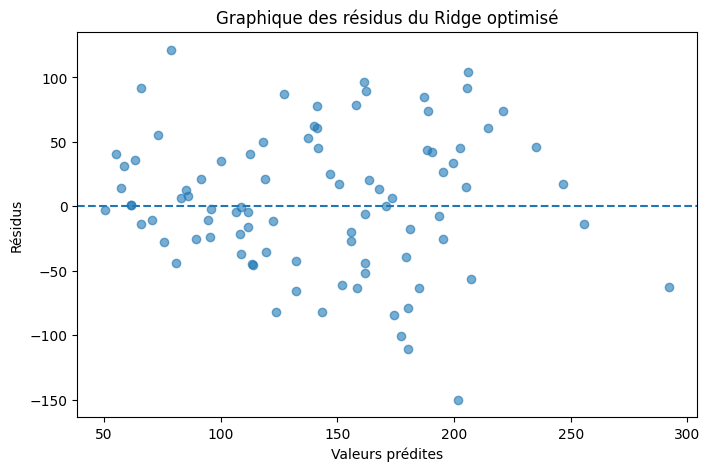

In [104]:
# Optimisation des hyperparamètres du Ridge

# Valeurs de alpha à tester
param_grid = {
    "ridge__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Création de la recherche par grille
grid_search_ridge = GridSearchCV(
    estimator=model_ridge,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Entraînement de GridSearchCV
grid_search_ridge.fit(X_train, y_train)

# Affichage du meilleur alpha et du meilleur score R² obtenu lors de la validation croisée
print("Meilleur alpha :", grid_search_ridge.best_params_["ridge__alpha"])
print("Meilleur R² CV :", grid_search_ridge.best_score_)

# Récupérer le meilleur modèle Ridge trouvé par GridSearchCV
ridge_opt = grid_search_ridge.best_estimator_

# Prédictions sur le jeu de test
y_pred_ridge_opt = ridge_opt.predict(X_test)

# Évaluation du Ridge optimisé
mae_ridge_opt = mean_absolute_error(y_test, y_pred_ridge_opt)
rmse_ridge_opt = np.sqrt(mean_squared_error(y_test, y_pred_ridge_opt))
r2_ridge_opt = r2_score(y_test, y_pred_ridge_opt)

print("MAE :", mae_ridge_opt)
print("RMSE :", rmse_ridge_opt)
print("R² :", r2_ridge_opt)

# Calcul des résidus
residus_ridge_opt = y_test - y_pred_ridge_opt

# Statistiques des résidus
print("Moyenne des résidus :", np.mean(residus_ridge_opt))
print("Écart-type des résidus :", np.std(residus_ridge_opt))

# Graphique des résidus
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_ridge_opt, residus_ridge_opt, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus du Ridge optimisé")
plt.show()

Les résidus du Ridge optimisé sont globalement centrés autour de zéro, mais leur dispersion reste importante. Le modèle ne présente pas de biais moyen marqué, mais certaines observations sont encore difficiles à prédire. Une légère variation de la dispersion selon les valeurs prédites semble possible.

**5.3. Modèle Lasso**

In [99]:
# Création du modèle Lasso simple avec standardisation
model_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=10000))
])

# Entraînement du modèle
model_lasso.fit(X_train, y_train)

# Prédictions
y_pred_lasso_simple = model_lasso.predict(X_test)

# Évaluation du Lasso simple
mae_lasso_simple = mean_absolute_error(y_test, y_pred_lasso_simple)
rmse_lasso_simple = np.sqrt(mean_squared_error(y_test, y_pred_lasso_simple))
r2_lasso_simple = r2_score(y_test, y_pred_lasso_simple)

print("MAE :", mae_lasso_simple)
print("RMSE :", rmse_lasso_simple)
print("R² :", r2_lasso_simple)

MAE : 42.80298373195777
RMSE : 53.14666587896139
R² : 0.46687670944102466


**Optimisation du Lasso**

Meilleur alpha : 1
Meilleur R² CV : 0.45413473438806645
Alpha retenu : 1
MAE : 42.80298373195777
RMSE : 53.14666587896139
R² : 0.46687670944102466
Moyenne des résidus : 3.4723756903907197
Écart-type des résidus : 53.03310947997244


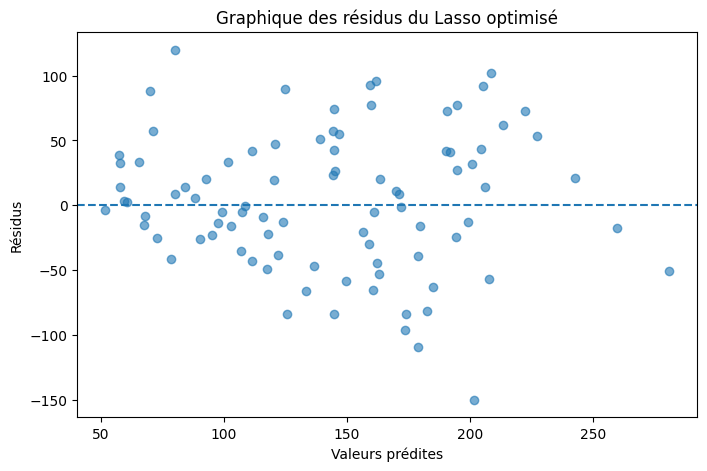

In [103]:
# Optimisation de l'hyperparamètre alpha du Lasso

param_grid = {
    "lasso__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search_lasso = GridSearchCV(
    estimator=model_lasso,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

grid_search_lasso.fit(X_train, y_train)

print("Meilleur alpha :", grid_search_lasso.best_params_["lasso__alpha"])
print("Meilleur R² CV :", grid_search_lasso.best_score_)

# Récupération du meilleur modèle Lasso trouvé par GridSearchCV
lasso_opt = grid_search_lasso.best_estimator_
print("Alpha retenu :", lasso_opt.named_steps["lasso"].alpha)

# Prédictions du Lasso optimisé sur le jeu de test
y_pred_lasso_opt = lasso_opt.predict(X_test)

# Évaluation du Lasso optimisé
mae_lasso_opt = mean_absolute_error(y_test, y_pred_lasso_opt)
rmse_lasso_opt = np.sqrt(mean_squared_error(y_test, y_pred_lasso_opt))
r2_lasso_opt = r2_score(y_test, y_pred_lasso_opt)

print("MAE :", mae_lasso_opt)
print("RMSE :", rmse_lasso_opt)
print("R² :", r2_lasso_opt)

# Calcul des résidus du Lasso optimisé
residus_lasso_opt = y_test - y_pred_lasso_opt

print("Moyenne des résidus :", np.mean(residus_lasso_opt))
print("Écart-type des résidus :", np.std(residus_lasso_opt))

# Graphique des résidus du Lasso optimisé
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lasso_opt, residus_lasso_opt, alpha=0.6)
plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus du Lasso optimisé")
plt.show()

Les résidus du Lasso optimisé sont globalement centrés autour de zéro, sans biais moyen important, mais leur dispersion reste élevée avec quelques erreurs extrêmes allant approximativement de −150 à +120. Le modèle présente donc encore des difficultés à prédire certaines observations.

**5.4. Elastic Net**

In [106]:
# Création du modèle Elastic Net avec standardisation
model_elastic = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(max_iter=10000))
])

# Entraînement du modèle
model_elastic.fit(X_train, y_train)

# Prédictions
y_pred_elastic_simple = model_elastic.predict(X_test)

# Évaluation de l'Elastic Net simple
mae_elastic_simple = mean_absolute_error(y_test, y_pred_elastic_simple)
rmse_elastic_simple = np.sqrt(mean_squared_error(y_test, y_pred_elastic_simple))
r2_elastic_simple = r2_score(y_test, y_pred_elastic_simple)

print("MAE :", mae_elastic_simple)
print("RMSE :", rmse_elastic_simple)
print("R² :", r2_elastic_simple)

MAE : 44.071832937303896
RMSE : 53.74667171146098
R² : 0.45477123774939976


**Optimisation de l'Elastic Net**

Meilleurs paramètres : {'elastic__alpha': 0.1, 'elastic__l1_ratio': 0.1}
Meilleur R² CV : 0.4560324781297006
MAE : 42.94953008405381
RMSE : 53.487834606919826
R² : 0.4600100965892058
Moyenne des résidus : 3.5480305479769187
Écart-type des résidus : 53.37002838829892


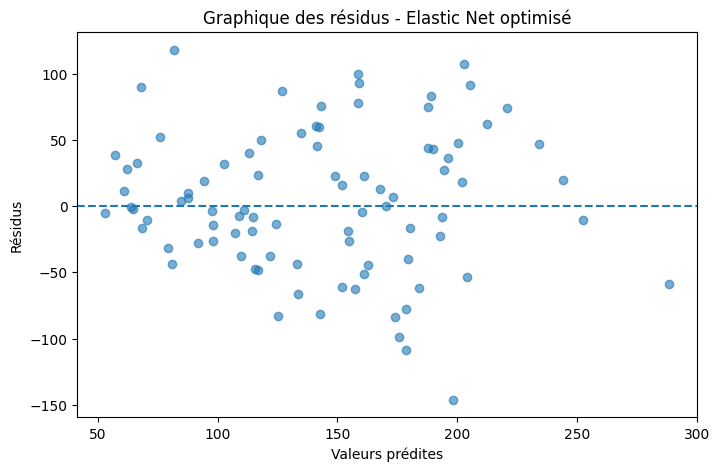

In [107]:
# Optimisation des hyperparamètres de l'Elastic Net

# Définition des valeurs d'alpha et de l1_ratio à tester
param_grid = {
    'elastic__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'elastic__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Mise en place d'une validation croisée à 5 plis pour rechercher les meilleurs hyperparamètres
grid_search_elastic = GridSearchCV(
    model_elastic,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Entraînement de GridSearchCV pour identifier la meilleure combinaison d'alpha et de l1_ratio
grid_search_elastic.fit(X_train, y_train)

# Affichage de la meilleure combinaison d'alpha et de l1_ratio
print("Meilleurs paramètres :", grid_search_elastic.best_params_)
print("Meilleur R² CV :", grid_search_elastic.best_score_)

# Récupération du modèle Elastic Net correspondant aux meilleurs hyperparamètres
elastic_net_optimise = grid_search_elastic.best_estimator_

# Génération des prédictions sur le jeu de test
y_pred_elastic_opt = elastic_net_optimise.predict(X_test)

# Évaluation du modèle Elastic Net optimisé
mae_elastic_opt = mean_absolute_error(y_test, y_pred_elastic_opt)
rmse_elastic_opt = np.sqrt(mean_squared_error(y_test, y_pred_elastic_opt))
r2_elastic_opt = r2_score(y_test, y_pred_elastic_opt)

print("MAE :", mae_elastic_opt)
print("RMSE :", rmse_elastic_opt)
print("R² :", r2_elastic_opt)

# Calcul des résidus
residus_elastic_opt = y_test - y_pred_elastic_opt

# Calcul de la moyenne et de l'écart-type des résidus
print("Moyenne des résidus :", np.mean(residus_elastic_opt))
print("Écart-type des résidus :", np.std(residus_elastic_opt))

# Visualisation des résidus en fonction des valeurs prédites
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_elastic_opt, residus_elastic_opt, alpha=0.6)
plt.axhline(y=0, linestyle='--')

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - Elastic Net optimisé")
plt.show()

Le graphique des résidus de l'Elastic Net optimisé montre des résidus globalement centrés autour de zéro, sans biais moyen important. Toutefois, leur dispersion reste élevée, avec des valeurs extrêmes proches de −150 et +120. La dispersion semble diminuer pour les valeurs prédites élevées, ce qui peut suggérer une légère hétéroscédasticité.

**Conclusion partielle**
| Modèle               |      MAE ↓ |     RMSE ↓ |      R² ↑ |     R² CV |
| -------------------- | ---------: | ---------: | --------: | --------: |
| Régression linéaire  | **42,790** |     53,850 |     0,453 |   ≈ 0,449 |
| Ridge optimisé       |     42,857 |     53,626 |     0,457 |     0,454 |
| **Lasso optimisé**   |     42,803 | **53,147** | **0,467** |     0,454 |
| Elastic Net optimisé |     42,950 |     53,488 |     0,460 | **0,456** |

Le Lasso optimisé est actuellement le meilleur des quatre selon le RMSE et le R² test.

Mais les différences restent faibles. Surtout, aucun de ces modèles n'explique plus de la moitié de la variance de la cible, puisque les R² restent autour de 0,45 à 0,47.

**5.5. Decision Tree Regressor**

In [108]:
# Création du modèle Decision Tree
tree = DecisionTreeRegressor(random_state=42)

# Entraînement du modèle
tree.fit(X_train, y_train)

# Prédictions
y_pred_tree = tree.predict(X_test)

# Évaluation du modèle
mae_tree = mean_absolute_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))
r2_tree = r2_score(y_test, y_pred_tree)

print("MAE :", mae_tree)
print("RMSE :", rmse_tree)
print("R² :", r2_tree)

MAE : 54.52808988764045
RMSE : 70.54642267903446
R² : 0.060653981041140725


**Optimisation des hyperparamètres**

Meilleurs paramètres : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
Meilleur R² CV : 0.2866720317302883
Meilleurs paramètres : {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
MAE : 45.18130783437863
RMSE : 55.62820579821017
R² : 0.4159289074356103
Moyenne des résidus : 0.6231163056374577
Écart-type des résidus : 55.624715787118156


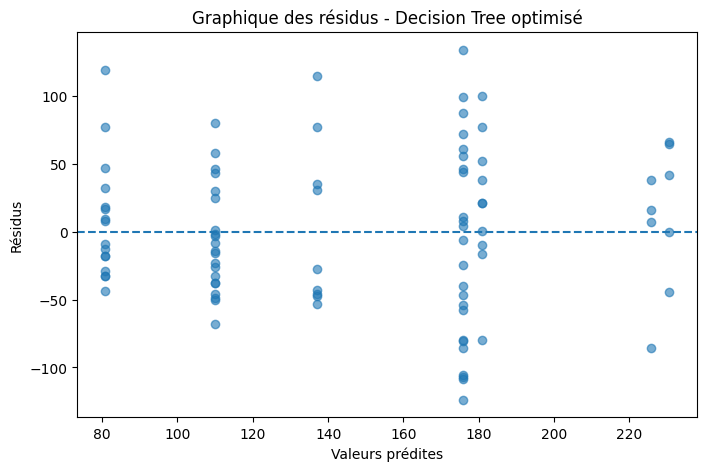

In [111]:
# Optimisation des hyperparamètres du Decision Tree

param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid_search_tree = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search_tree.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search_tree.best_params_)
print("Meilleur R² CV :", grid_search_tree.best_score_)

# Récupération du meilleur modèle Decision Tree
tree_opt = grid_search_tree.best_estimator_
print("Meilleurs paramètres :", grid_search_tree.best_params_)

# Prédictions du Decision Tree optimisé sur le jeu de test
y_pred_tree_opt = tree_opt.predict(X_test)

# Évaluation du Decision Tree optimisé
mae_tree_opt = mean_absolute_error(y_test, y_pred_tree_opt)
rmse_tree_opt = np.sqrt(mean_squared_error(y_test, y_pred_tree_opt))
r2_tree_opt = r2_score(y_test, y_pred_tree_opt)

print("MAE :", mae_tree_opt)
print("RMSE :", rmse_tree_opt)
print("R² :", r2_tree_opt)

# Calcul des résidus du Decision Tree optimisé
residus_tree_opt = y_test - y_pred_tree_opt
print("Moyenne des résidus :", np.mean(residus_tree_opt))
print("Écart-type des résidus :", np.std(residus_tree_opt))

# Graphique des résidus du Decision Tree optimisé

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_tree_opt,
    residus_tree_opt,
    alpha=0.6
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - Decision Tree optimisé")

plt.show()

Le graphique des résidus du Decision Tree optimisé montre une dispersion importante autour de zéro, avec des erreurs pouvant atteindre environ ±150. Les résidus ne présentent pas de biais moyen significatif, ce que confirme leur moyenne de 0,62. La structure régulière du graphique est cohérente avec le fonctionnement d'un arbre peu profond, qui produit des prédictions par paliers.

**5.6 Random Forest**

In [116]:
# Création du modèle Random Forest simple
random_forest = RandomForestRegressor(
    random_state=42
)

# Entraînement du modèle
random_forest.fit(X_train, y_train)

# Prédictions
y_pred_rf_simple = random_forest.predict(X_test)

# Évaluation du Random Forest simple
mae_rf_simple = mean_absolute_error(y_test, y_pred_rf_simple)
rmse_rf_simple = np.sqrt(mean_squared_error(y_test, y_pred_rf_simple))
r2_rf_simple = r2_score(y_test, y_pred_rf_simple)

print("MAE :", mae_rf_simple)
print("RMSE :", rmse_rf_simple)
print("R² :", r2_rf_simple)

MAE : 44.053033707865175
RMSE : 54.332408273184846
R² : 0.4428225673999313


d:\UserGenerator\env\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleurs paramètres : {'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 300}
Meilleur R² CV : 0.4132734834655504
MAE : 43.522001445397116
RMSE : 53.52999791849473
R² : 0.4591584361553378
Moyenne des résidus : -0.6147915584811205
Écart-type des résidus : 53.526467364227116


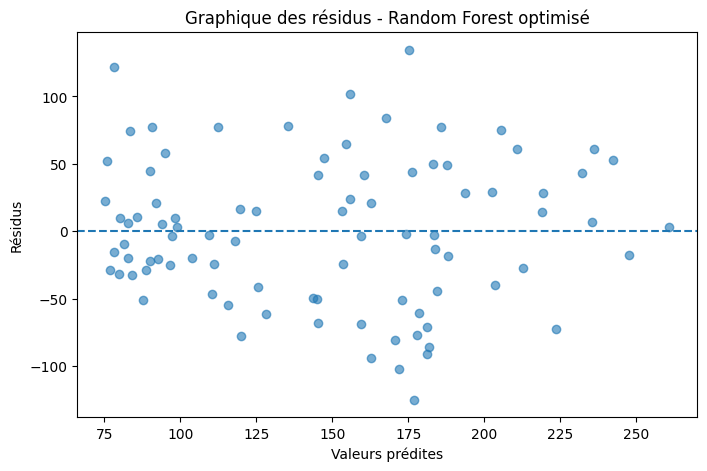

In [113]:
# Optimisation des hyperparamètres du Random Forest

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

# Entraînement de GridSearchCV
grid_search_rf.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print("Meilleurs paramètres :", grid_search_rf.best_params_)
print("Meilleur R² CV :", grid_search_rf.best_score_)

# Récupération du meilleur modèle
rf_opt = grid_search_rf.best_estimator_

# Prédictions sur le jeu de test
y_pred_rf_opt = rf_opt.predict(X_test)

# Évaluation du Random Forest optimisé
mae_rf_opt = mean_absolute_error(y_test, y_pred_rf_opt)
rmse_rf_opt = np.sqrt(mean_squared_error(y_test, y_pred_rf_opt))
r2_rf_opt = r2_score(y_test, y_pred_rf_opt)

print("MAE :", mae_rf_opt)
print("RMSE :", rmse_rf_opt)
print("R² :", r2_rf_opt)

# Calcul des résidus
residus_rf_opt = y_test - y_pred_rf_opt

# Statistiques des résidus
print("Moyenne des résidus :", np.mean(residus_rf_opt))
print("Écart-type des résidus :", np.std(residus_rf_opt))

# Graphique des résidus
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_rf_opt,
    residus_rf_opt,
    alpha=0.6
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - Random Forest optimisé")

plt.show()

Le Random Forest optimisé améliore nettement le Random Forest simple, avec un R² passant de 0,443 à 0,459. Cependant, il reste légèrement inférieur au Lasso optimisé, qui conserve actuellement la meilleure performance avec un R² de 0,467 et un RMSE de 53,147. Les résidus du Random Forest sont très bien centrés autour de zéro, mais leur dispersion reste importante.

Les résidus du Random Forest optimisé sont globalement répartis autour de zéro, sans tendance systématique apparente. Cependant, leur dispersion reste importante, avec des erreurs pouvant atteindre environ ±120. Une variation de la dispersion selon les valeurs prédites semble possible, mais elle nécessiterait des tests complémentaires pour confirmer une éventuelle hétéroscédasticité.

**5.7. Gradient Boosting Regressor**

In [115]:
# Création du modèle Gradient Boosting simple
gradient_boosting = GradientBoostingRegressor(random_state=42)

# Entraînement du modèle
gradient_boosting.fit(X_train, y_train)

# Prédictions
y_pred_gb_simple = gradient_boosting.predict(X_test)

# Évaluation du Gradient Boosting simple
mae_gb_simple = mean_absolute_error(y_test, y_pred_gb_simple)
rmse_gb_simple = np.sqrt(mean_squared_error(y_test, y_pred_gb_simple))
r2_gb_simple = r2_score(y_test, y_pred_gb_simple)

print("MAE :", mae_gb_simple)
print("RMSE :", rmse_gb_simple)
print("R² :", r2_gb_simple)

MAE : 44.60329704365656
RMSE : 53.837130987019755
R² : 0.4529343796683364


**Optimisation des hyperparamètres**

Meilleurs paramètres : {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Meilleur R² CV : 0.4127426804858466
MAE : 42.521158107384366
RMSE : 52.48468928355292
R² : 0.48007479967663236
Moyenne des résidus : -3.616861399802175
Écart-type des résidus : 52.35991713902644


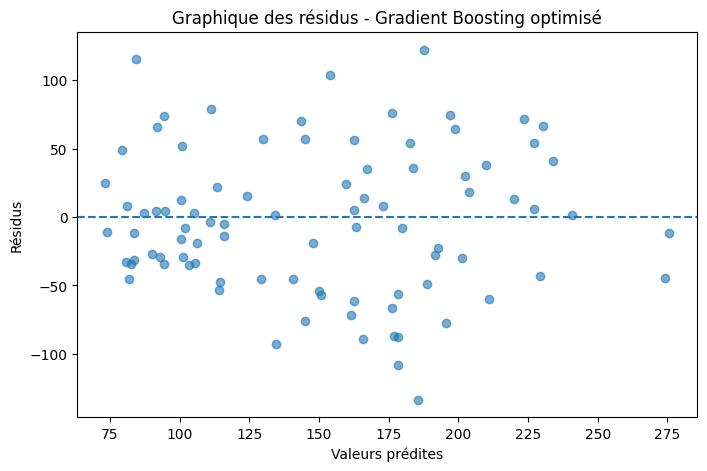

In [117]:
# Optimisation des hyperparamètres du Gradient Boosting

param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=2
)

# Entraînement de GridSearchCV
grid_search_gb.fit(X_train, y_train)

# Affichage des meilleurs paramètres
print("Meilleurs paramètres :", grid_search_gb.best_params_)
print("Meilleur R² CV :", grid_search_gb.best_score_)

# Récupération du meilleur modèle
gb_opt = grid_search_gb.best_estimator_

# Prédictions sur le jeu de test
y_pred_gb_opt = gb_opt.predict(X_test)

# Évaluation du Gradient Boosting optimisé
mae_gb_opt = mean_absolute_error(y_test, y_pred_gb_opt)
rmse_gb_opt = np.sqrt(mean_squared_error(y_test, y_pred_gb_opt))
r2_gb_opt = r2_score(y_test, y_pred_gb_opt)

print("MAE :", mae_gb_opt)
print("RMSE :", rmse_gb_opt)
print("R² :", r2_gb_opt)

# Calcul des résidus
residus_gb_opt = y_test - y_pred_gb_opt

# Statistiques des résidus
print("Moyenne des résidus :", np.mean(residus_gb_opt))
print("Écart-type des résidus :", np.std(residus_gb_opt))

# Graphique des résidus
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_gb_opt,
    residus_gb_opt,
    alpha=0.6
)

# Ligne horizontale à zéro
plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - Gradient Boosting optimisé")

plt.show()

Le Gradient Boosting optimisé est actuellement le meilleur modèle testé. Il obtient un MAE de 42,52, un RMSE de 52,48 et un R² de 0,480 sur le jeu de test. Il améliore les performances du Gradient Boosting simple et dépasse le Lasso optimisé. Toutefois, l'écart entre le R² CV de 0,413 et le R² test de 0,480 doit être surveillé avant de conclure définitivement à sa supériorité.

Le graphique des résidus du Gradient Boosting optimisé montre des erreurs globalement réparties autour de zéro, sans structure systématique évidente. La dispersion reste toutefois importante, avec des résidus pouvant atteindre environ ±120. La moyenne de −3,62 indique un léger biais négatif, mais celui-ci reste modéré.

**5.8. XGBoost Regressor**

In [119]:
from xgboost import XGBRegressor

# Création du modèle XGBoost simple
xgb = XGBRegressor(
    random_state=42
)

# Entraînement du modèle
xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb_simple = xgb.predict(X_test)

# Évaluation du XGBoost simple
mae_xgb_simple = mean_absolute_error(y_test, y_pred_xgb_simple)
rmse_xgb_simple = np.sqrt(mean_squared_error(y_test, y_pred_xgb_simple))
r2_xgb_simple = r2_score(y_test, y_pred_xgb_simple)

print("MAE :", mae_xgb_simple)
print("RMSE :", rmse_xgb_simple)
print("R² :", r2_xgb_simple)

MAE : 46.38896564955122
RMSE : 57.88783670048563
R² : 0.3675149756138415


**Optimisation des hyperparamètres**

Meilleurs paramètres : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Meilleur R² CV : 0.4129963945457953
MAE : 43.395656542831595
RMSE : 54.00268793334141
R² : 0.4495645948905912
Moyenne des résidus : -0.6395766869019927
Écart-type des résidus : 53.99890041183644


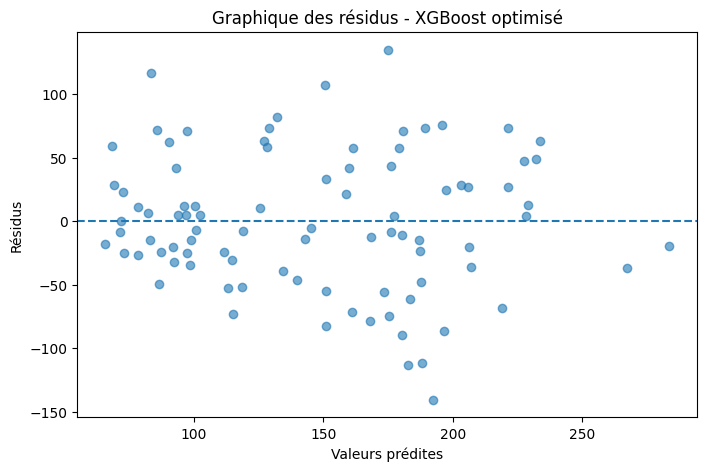

In [121]:
# Optimisation des hyperparamètres de XGBoost

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 6],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9],
    "colsample_bytree": [0.8, 0.9]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=2
)

# Recherche des meilleurs hyperparamètres
grid_search_xgb.fit(X_train, y_train)

# Meilleurs paramètres
print("Meilleurs paramètres :", grid_search_xgb.best_params_)
print("Meilleur R² CV :", grid_search_xgb.best_score_)

# Récupération du meilleur modèle
xgb_opt = grid_search_xgb.best_estimator_

# Prédictions sur le jeu de test
y_pred_xgb_opt = xgb_opt.predict(X_test)

# Évaluation du XGBoost optimisé
mae_xgb_opt = mean_absolute_error(y_test, y_pred_xgb_opt)
rmse_xgb_opt = np.sqrt(mean_squared_error(y_test, y_pred_xgb_opt))
r2_xgb_opt = r2_score(y_test, y_pred_xgb_opt)

print("MAE :", mae_xgb_opt)
print("RMSE :", rmse_xgb_opt)
print("R² :", r2_xgb_opt)

# Calcul des résidus
residus_xgb_opt = y_test - y_pred_xgb_opt

# Statistiques des résidus
print("Moyenne des résidus :", np.mean(residus_xgb_opt))
print("Écart-type des résidus :", np.std(residus_xgb_opt))

# Graphique des résidus
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_xgb_opt,
    residus_xgb_opt,
    alpha=0.6
)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus - XGBoost optimisé")

plt.show()

XGBoost optimisé améliore fortement le modèle XGBoost simple, mais ses performances restent inférieures à celles du Gradient Boosting optimisé. Avec un R² de 0,450, un RMSE de 54,003 et un MAE de 43,396, XGBoost ne devient pas le meilleur modèle de notre étude. Le Gradient Boosting reste actuellement en tête avec un R² de 0,480 et un RMSE de 52,485.

Le graphique des résidus du XGBoost optimisé montre une répartition globalement équilibrée autour de zéro, sans structure systématique évidente. Toutefois, la dispersion reste importante, avec des erreurs pouvant atteindre environ −150 à +120. Le modèle présente donc un faible biais moyen, mais certaines observations restent difficiles à prédire.

**6. Tableau comparatif final**

| Modèle                         |      MAE ↓ |     RMSE ↓ | R² test ↑ | R² CV ↑ | Écart R² test/CV |
| ------------------------------ | ---------: | ---------: | --------: | ------: | ---------------: |
| **Régression linéaire**        |     42,790 |     53,850 |     0,453 | ≈ 0,449 |     ≈ **+0,004** |
| **Ridge optimisé**             |     42,857 |     53,626 |     0,457 |   0,454 |       **+0,003** |
| **Lasso optimisé**             |     42,803 |     53,147 |     0,467 |   0,454 |       **+0,013** |
| **Elastic Net optimisé**       |     42,950 |     53,488 |     0,460 |   0,456 |       **+0,004** |
| **Decision Tree optimisé**     |     45,181 |     55,628 |     0,416 |   0,287 |       **+0,129** |
| **Random Forest optimisé**     |     43,522 |     53,530 |     0,459 |   0,413 |       **+0,046** |
| **Gradient Boosting optimisé** | **42,521** | **52,485** | **0,480** |   0,413 |       **+0,067** |
| **XGBoost optimisé**           |     43,396 |     54,003 |     0,450 |   0,413 |       **+0,037** |


Après comparaison des différents modèles de régression, le Gradient Boosting optimisé obtient les meilleures performances sur le jeu de test, avec un MAE de 42,52, un RMSE de 52,48 et un R² de 0,480. Il devance légèrement les modèles linéaires régularisés, notamment le Lasso et l'Elastic Net. Toutefois, son R² moyen en validation croisée de 0,413 est inférieur à celui du Lasso (0,454) et de l'Elastic Net (0,456), ce qui invite à rester prudent quant à sa capacité de généralisation. Globalement, les modèles expliquent environ 45 à 48 % de la variabilité de la progression de la maladie dans notre jeu de données. Le Gradient Boosting constitue donc le meilleur modèle selon les performances obtenues sur le jeu de test, tandis que les modèles linéaires régularisés présentent une meilleure stabilité en validation croisée.

**Pour la suite de l'analyse, le Gradient Boosting optimisé sera retenu comme modèle final en raison de ses meilleures performances prédictives sur le jeu de test.**

**7. Importance des variables**

  Variable  Importance
2      bmi    0.419472
8       s5    0.319270
3       bp    0.103581
6       s3    0.041167
9       s6    0.029573
7       s4    0.021699
0      age    0.019994
4       s1    0.019987
5       s2    0.018845
1      sex    0.006412


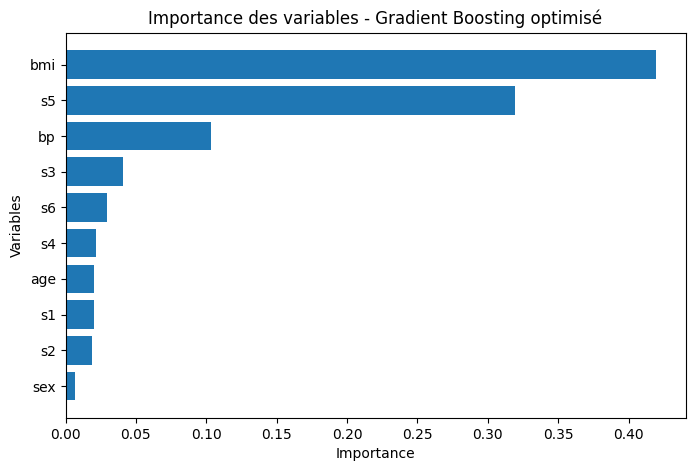

In [122]:
# Importance des variables du modèle final

importances = gb_opt.feature_importances_

importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importance": importances
})

# Trier les variables par importance décroissante
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df)

# Graphique de l'importance des variables

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Variable"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variables")
plt.title("Importance des variables - Gradient Boosting optimisé")
plt.gca().invert_yaxis()

plt.show()

L'interprétation du Gradient Boosting optimisé montre que le BMI (bmi) constitue la variable la plus importante pour les prédictions, avec une importance de 41,95 %, suivi de la variable s5 avec 31,93 % et de la pression artérielle (bp) avec 10,36 %. À elles seules, les variables bmi et s5 représentent environ 73,9 % de l'importance totale du modèle. Les autres variables présentent une contribution plus limitée, tandis que sex est la variable la moins importante avec 0,64 %. Ces résultats indiquent que le modèle s'appuie principalement sur le BMI et s5 pour prédire la progression de la maladie. Toutefois, ces importances mesurent une contribution à la prédiction et ne doivent pas être interprétées comme des relations causales.

**8. Calcul des valeurs SHAP**

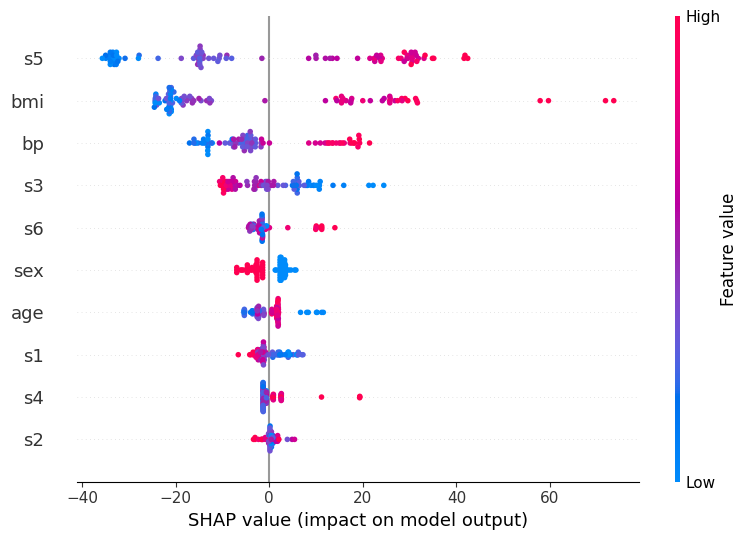

In [123]:
# Analyse SHAP du modèle final
import shap

# Création de l'explainer SHAP
explainer = shap.TreeExplainer(gb_opt)

# Calcul des valeurs SHAP sur le jeu de test
shap_values = explainer.shap_values(X_test)

# Résumé global des influences
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns
)

L'analyse SHAP montre que les variables s5, bmi, bp et s3 sont les principales variables contribuant aux prédictions du Gradient Boosting optimisé. Les valeurs élevées de s5, bmi, bp et s6 tendent à augmenter les prédictions du modèle, tandis que les valeurs élevées de s3 et s1 tendent plutôt à les diminuer. Les variables age, s4 et s2 présentent une influence plus limitée. Ces résultats décrivent le comportement prédictif du modèle et ne doivent pas être interprétés comme des relations causales.

**9. Conclusion générale**

Cette étude avait pour objectif de prédire la progression de la maladie à partir des variables du dataset Diabetes de scikit-learn. Plusieurs familles de modèles ont été comparées, notamment la régression linéaire, Ridge, Lasso, Elastic Net, Decision Tree, Random Forest, Gradient Boosting et XGBoost. Après optimisation des hyperparamètres et évaluation sur un jeu de test indépendant, le Gradient Boosting optimisé obtient les meilleures performances avec un MAE de 42,52, un RMSE de 52,48 et un R² de 0,480. L'analyse des importances montre que le BMI (bmi), la variable s5 et la pression artérielle (bp) constituent les variables les plus importantes pour les prédictions. Malgré ses performances, le modèle n'explique qu'environ 48 % de la variabilité de la cible et présente donc des limites prédictives. Les résultats doivent par ailleurs être interprétés comme des relations prédictives du modèle et non comme des relations causales.